# K-Means Clustering — Complete Notebook

This notebook merges everything from the two original notebooks (`archive/K_Means_Visualizer.ipynb` and `archive/K_Means_Clustering_using_Scikit_Learn (1).ipynb`) plus the handwritten theory notes (`K Means Clustering.pdf`), ordered for a clean learning flow:

1. **Theory** — centroid idea, Lloyd's algorithm, SSE/inertia objective, why cost decreases
2. **Manual / visual intuition** — build centroids by hand, step through Lloyd's algorithm one step at a time (from the visualizer notebook)
3. **Full scikit-learn implementation** — real dataset (Iris), `KMeans` fit, cluster visualization, centroids
4. **Model evaluation for choosing k** — Elbow method (WCSS/inertia) and Silhouette score, side by side
5. **Random-initialization sensitivity problem** — local minima, and how `n_init` / `k-means++` fixes it
6. **Where K-Means fails** — non-spherical data (`make_moons`) and a pointer to DBSCAN

See the companion `README.md` in this folder for the full theory write-up, formulas, and a hand-worked numeric example.


## 1. Theory Recap (from the handwritten notes)

**Supervised vs Unsupervised.** In supervised learning every row has a label/target `y` (True label given). In unsupervised learning there is **no label** — the model only sees `X` and must find structure on its own.

**Unsupervised learning tasks:**
- **Clustering** — group similar rows together (this notebook)
- **Dimensionality Reduction** — compress features while keeping structure (e.g. PCA)
- **Anomaly Detection** — find points that don't fit any group

**Clustering = Grouping.** Example: an e-commerce store groups customers by *spending* and *expensiveness of items bought* into segments (budget shoppers, big spenders, etc.) without ever being told the "correct" segment.

**K-Means idea.** `K` = how many clusters we want (a number we choose up front). A **centroid** is the "average point" (center) of a cluster — literally the mean of all points currently assigned to it.

**Procedure (Lloyd's algorithm), from the notes:**
1. Decide how many clusters (`k`). Create `k` centroids (commonly at random points to start).
2. **Assignment step** — assign every point to its nearest centroid, using a distance measure (Euclidean distance).
3. **Update step** — recompute each centroid as the mean of the points now assigned to it. This *corrects* the centroid position for better clustering.
4. **Re-clustering** — because centroids moved, re-assign every point to its (possibly new) nearest centroid.
5. Repeat steps 2–4 in a loop until centroids stop moving (finite convergence).

**Cost / Objective function — SSE (Sum of Squared Errors)**, a.k.a. **WCSS** or **inertia**:

For a candidate point and two candidate centroids, e.g. point `(5,7)` vs centroids `(3,2)` and `(2,3)`:
- distance² to `(3,2)` → `(5-3)² + (7-2)² = 4 + 25 = 29`
- distance² to `(2,3)` → `(5-2)² + (7-3)² = 9 + 16 = 25`

Since `25 < 29`, the point is assigned to the centroid `(2,3)`. Summing every point's squared distance to *its own* cluster's centroid, per cluster, gives that cluster's SSE; adding all clusters' SSE gives the **Total SSE**:

`Total SSE = SSE_cluster_1 + SSE_cluster_2 + ... + SSE_cluster_k`

**Why does the cost always decrease (or stay the same), never increase?**
- *Assignment step*: centroids are held fixed, and every point is moved to whichever centroid is **closer** than its current one → the sum of squared distances cannot go up.
- *Update step*: assignments are held fixed, and the centroid is moved to the **mean** of its assigned points. The mean is exactly the point that minimizes the sum of squared distances to a fixed set of points, so this step cannot increase the cost either.

Small numeric illustration from the notes: two points `(2,3)` and `(6,3)` currently near a centroid guess `(3,3)`:
- SSE using centroid `(3,3)`: `(3-2)²+(3-3)² = 1` and `(6-3)²+(3-3)² = 9` → total `1 + 9 = 10`
- The true mean of `(2,3)` and `(6,3)` is `((2+6)/2, 3) = (4,3)`
- SSE using the mean centroid `(4,3)`: `(4-2)²+(3-3)² = 4` and `(6-4)²+(3-3)² = 4` → total `4 + 4 = 8`

`8 < 10` — moving the centroid to the mean strictly reduced the cost. This is why the update step always helps (or, at worst, leaves the cost unchanged if the centroid was already the mean).

**Choosing `n_clusters` (k):**
1. **Domain knowledge** — you already know roughly how many natural groups should exist.
2. **Elbow method** — plot cost (inertia) against k and look for the "elbow" bend (covered with code below).

Because there's no ground-truth label in clustering, we can't use accuracy/R² to judge quality — instead we use metrics like **inertia (Elbow)** and **Silhouette score**, both demonstrated later in this notebook.


## 2. Manual & Visual Intuition (from the original Visualizer notebook)

Before letting `sklearn` do everything, let's build intuition by hand:

- **2A** — an interactive widget where you add 2D points with sliders and watch the centroid (the mean point) update live, with the full arithmetic printed out (sum of x, sum of y, divide by n).
- **2B** — a step-by-step (button-driven) implementation of Lloyd's algorithm on a small synthetic dataset: click "Next Step" to (1) assign points to the nearest of 2 centroids, (2) see the SSE/cost breakdown per cluster, (3) recompute centroids as the mean of their assigned points, and watch the cost curve fall until it stabilizes for 3 consecutive steps ("FINISHED" message).
- **2C** — an automated version of the elbow idea on `make_blobs` data (this becomes the full Elbow Method section later, reused here for the original demonstration).

Run the two widget cells below in a live Jupyter session (with `ipywidgets` installed and enabled) to interact with the sliders/buttons. In a plain script/CI execution these still run and render a static frame.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
import ipywidgets as widgets

# State to store points
points = []
output = widgets.Output()

def update_view():
    with output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_title("Centroid Plot")
        ax.grid(True, linestyle='--', alpha=0.6)

        if points:
            pts = np.array(points)
            ax.scatter(pts[:, 0], pts[:, 1], color='blue', label='Points')

            n = len(points)
            sum_x = np.sum(pts[:, 0])
            sum_y = np.sum(pts[:, 1])
            cx, cy = sum_x / n, sum_y / n

            ax.scatter(cx, cy, color='red', marker='x', s=150, linewidths=3, label='Centroid')
            ax.legend()
            plt.show()

            print(f"--- Detailed Calculation (n = {n} points) ---")
            for i, (px, py) in enumerate(points):
                print(f"Point {i+1}: ({px:.2f}, {py:.2f})")

            print(f"\nSum of X = {' + '.join([f'{p[0]:.2f}' for p in points])} = {sum_x:.2f}")
            print(f"Sum of Y = {' + '.join([f'{p[1]:.2f}' for p in points])} = {sum_y:.2f}")

            print(f"\nCentroid X (Cx) = Sum(X) / n = {sum_x:.2f} / {n} = {cx:.4f}")
            print(f"Centroid Y (Cy) = Sum(Y) / n = {sum_y:.2f} / {n} = {cy:.4f}")
            print(f"Final Centroid Position: ({cx:.4f}, {cy:.4f})")
        else:
            ax.text(5, 5, "Use sliders to add points", ha='center')
            plt.show()
            print("No points added yet.")

x_slider = widgets.FloatSlider(min=0, max=10, step=0.1, description='X:')
y_slider = widgets.FloatSlider(min=0, max=10, step=0.1, description='Y:')
add_button = widgets.Button(description="Add Point", button_style='success')
reset_button = widgets.Button(description="Reset", button_style='danger')

def on_add_clicked(b):
    points.append((x_slider.value, y_slider.value))
    update_view()

def on_reset_clicked(b):
    global points
    points = []
    update_view()

add_button.on_click(on_add_clicked)
reset_button.on_click(on_reset_clicked)

ui = widgets.VBox([widgets.HBox([x_slider, y_slider, add_button, reset_button]), output])
display(ui)
update_view()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# State Variables
state = {
    'X_interactive': None,
    'centroids': None,
    'labels': None,
    'iteration': 0,
    'history_sse': [],
    'converged_at': None,
    'buffer_steps': 0
}

def initialize_data():
    # Generates a new 'beautiful' dataset with a bridge and resets the algorithm.
    cluster_a = np.random.normal(loc=[2, 2], scale=0.5, size=(10, 2))
    cluster_b = np.random.normal(loc=[8, 8], scale=0.5, size=(10, 2))
    bridge = np.array([[3.5, 3.5], [4.5, 4.5], [5.5, 5.5], [6.5, 6.5]])
    state['X_interactive'] = np.vstack([cluster_a, cluster_b, bridge])
    reset_algo(None)

def reset_algo(b):
    # Resets the algorithm state to step 0.
    state['centroids'] = np.array([[0.2, 0.8], [0.8, 0.2]])
    state['labels'] = np.zeros(state['X_interactive'].shape[0], dtype=int)
    state['iteration'] = 0
    state['history_sse'] = []
    state['converged_at'] = None
    state['buffer_steps'] = 0
    next_button.disabled = False
    next_button.description = "Next Step (Iterate)"
    run_kmeans_step(None)

output_area = widgets.Output()

def run_kmeans_step(b):
    with output_area:
        X = state['X_interactive']

        # 1. Assignment Step
        distances = np.linalg.norm(X[:, np.newaxis] - state['centroids'], axis=2)
        state['labels'] = np.argmin(distances, axis=1)

        # 2. Calculation of Cost (SSE)
        total_sse = 0
        sse_details = []
        for k in range(2):
            cluster_points = X[state['labels'] == k]
            if len(cluster_points) > 0:
                sq_dist = np.sum((cluster_points - state['centroids'][k])**2)
                total_sse += sq_dist
                sse_details.append(f"Cluster {k+1} SSE: {sq_dist:.4f} ({len(cluster_points)} points)")
            else:
                sse_details.append(f"Cluster {k+1} is empty.")

        state['history_sse'].append(total_sse)

        if b is not None and b.description.startswith("Next"):
            state['iteration'] += 1

        # 3. Visualization
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f9f9f9')

        colors = ['#3498db', '#2ecc71']
        for k in range(2):
            idx = state['labels'] == k
            ax1.scatter(X[idx, 0], X[idx, 1], c=colors[k], label=f'Group {k+1}', s=70, alpha=0.8, edgecolors='white')
            ax1.scatter(state['centroids'][k, 0], state['centroids'][k, 1], c='red', marker='X', s=250, edgecolors='black', label=f'Centroid {k+1}', zorder=10)

        status = "Iterating..." if state['converged_at'] is None else f"STABILITY CHECK ({state['buffer_steps']}/3)"
        ax1.set_title(f"Step {state['iteration']}: {status}", fontsize=14, fontweight='bold')
        ax1.set_xlim(-1, 11); ax1.set_ylim(-1, 11)
        ax1.grid(True, linestyle='--', alpha=0.3)

        ax2.plot(range(1, len(state['history_sse']) + 1), state['history_sse'], marker='o', color='#e74c3c', linewidth=2)
        ax2.set_title(f"Cost Progress (SSE): {total_sse:.2f}", fontsize=14, fontweight='bold')
        ax2.set_xlabel("Iteration Step")
        ax2.set_ylabel("Total SSE")
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # 4. Explicit Text Output for Math/SSE Breakdown
        print(f"\n--- MATHEMATICAL BREAKDOWN (STEP {state['iteration']}) ---")
        for detail in sse_details: print(detail)
        print(f"Current Total SSE = {total_sse:.4f}")

        print("\n--- COST HISTORY ---")
        for i, val in enumerate(state['history_sse']):
            print(f"Step {i}: SSE = {val:.4f}")

        # 5. Update Centroids & Stopping Logic
        if b is not None and b.description.startswith("Next"):
            new_centroids = np.array([X[state['labels'] == k].mean(axis=0) if len(X[state['labels'] == k]) > 0 else state['centroids'][k] for k in range(2)])

            if np.allclose(state['centroids'], new_centroids, atol=1e-4):
                if state['converged_at'] is None: state['converged_at'] = state['iteration']
                state['buffer_steps'] += 1
                next_button.description = f"Confirm Stability ({state['buffer_steps']}/3)"
                if state['buffer_steps'] >= 3:
                    print("\n[FINISHED] Centroids are stable. Minimum SSE reached.")
                    next_button.disabled = True
            else:
                state['centroids'] = new_centroids

# UI Setup
next_button = widgets.Button(description="Next Step (Iterate)", button_style='primary', layout=widgets.Layout(width='200px'))
randomize_button = widgets.Button(description="Randomize & Reset", button_style='warning', layout=widgets.Layout(width='200px'))

next_button.on_click(run_kmeans_step)
randomize_button.on_click(lambda b: initialize_data())

display(widgets.HBox([next_button, randomize_button]), output_area)
initialize_data()

Output()

## 3. Full scikit-learn Implementation — Iris Dataset

Now the "just call sklearn" workflow on a real dataset: load data, scale features, fit `KMeans`, inspect labels, visualize, and read off inertia.


### 3.1 Import Libraries

`numpy` / `pandas` for data handling, `matplotlib` / `seaborn` for plotting, `sklearn.datasets` to load Iris, `StandardScaler` for feature scaling, and `KMeans` for clustering.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

### 3.2 Load the Iris Dataset

The classic Iris dataset (150 rows): sepal length, sepal width, petal length, petal width for 3 species. Loaded into a pandas DataFrame.

In [4]:
df = load_iris(as_frame=True).frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### 3.3 Data Overview

`df.info()` gives a concise summary: number of entries, columns, non-null counts, dtypes — useful to spot missing values or wrong types quickly.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### 3.4 Feature Selection

For this example we'll cluster using only two features: `sepal length (cm)` and `sepal width (cm)`, so the result is easy to plot in 2D.

In [6]:
X = df[['sepal length (cm)','sepal width (cm)']]
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


### 3.5 Feature Scaling

K-Means is **distance-based**, so it is sensitive to feature scale — a feature measured in the hundreds would dominate the distance calculation over a feature measured in single digits. `StandardScaler` rescales every feature to mean 0, std 1 so all features contribute fairly.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 3.6 Initialize the K-Means Model

- `n_clusters=3` — we expect 3 clusters (matching the 3 Iris species)
- `init='k-means++'` — smart initialization that spreads out the initial centroids, converges faster and avoids bad local minima more often than pure random init
- `max_iter=400` — maximum number of Lloyd's-algorithm iterations
- `random_state=42` — reproducibility

In [8]:
kmeans = KMeans(n_clusters=3,
                init = 'k-means++',
                max_iter = 400,
                random_state=42)

### 3.7 Fit the Model

`kmeans.fit(X_scaled)` runs Lloyd's algorithm: assign → update → repeat, until convergence.

In [9]:
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",400
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[

### 3.8 Inspect Cluster Labels

`kmeans.labels_` holds the cluster id assigned to every row.

In [10]:
print(kmeans.labels_[:80])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 2 2 2 2 2 2 2 2 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 0 0 0 0 1 1]


### 3.9 Add Cluster Labels to the DataFrame

Attach the predicted `clusters` column back onto `df` so we can compare/visualize against the original features (and, out of curiosity, the true `target`).

In [11]:
df['clusters'] = kmeans.labels_
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,clusters
0,5.1,3.5,1.4,0.2,0,2
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,2
3,4.6,3.1,1.5,0.2,0,2
4,5.0,3.6,1.4,0.2,0,2


### 3.10 Visualize the Clusters (with Centroids)

A scatter plot of the two chosen features, colored by predicted cluster. We also plot the centroids (in the *original* feature space, by inverse-transforming the scaled centroids) as large red X markers so it's clear what each cluster is centered on.

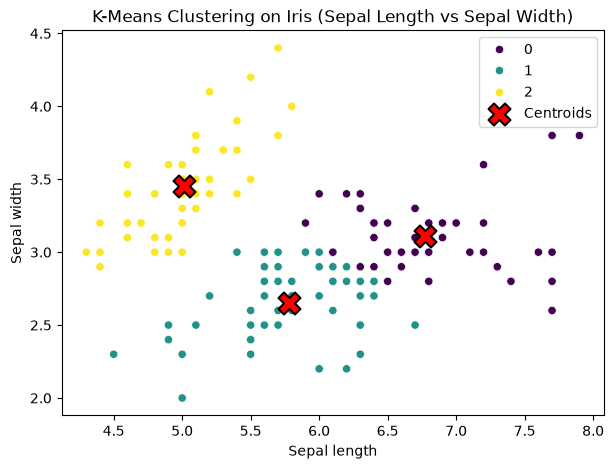

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    x = df['sepal length (cm)'],
    y = df['sepal width (cm)'],
    hue = df['clusters'],
    palette = 'viridis'
)

# Plot centroids back in original (unscaled) feature space
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='red', marker='X', s=250, edgecolor='black', linewidths=1.5,
            label='Centroids', zorder=5)

plt.title("K-Means Clustering on Iris (Sepal Length vs Sepal Width)")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.legend()
plt.show()

### 3.11 What is Inertia?

**Inertia** measures how "tight"/compact the clusters are — it's the sum of squared distances of every point to its own cluster's centroid (exactly the **WCSS / SSE** from the theory section). Smaller inertia = points closer to their centroid = tighter clusters. Inertia will *always* decrease as `k` increases (more clusters → each point has a nearer centroid to hug), so we never use inertia alone to justify a bigger `k` — see the Elbow Method below.

In [13]:
print(f"Inertia: {kmeans.inertia_}")

Inertia: 102.62862638978045


### 3.12 Inertia vs. SSE (Sum of Squared Errors)

**Yes — they are the exact same thing.** SSE is the general statistical name (sum of squared distance-errors between points and their assigned center); `inertia_` is simply what scikit-learn calls that value for `KMeans`. If an exam/teacher asks for "SSE", read off `kmeans.inertia_`.

## 4. Choosing k — Elbow Method and Silhouette Score, Side by Side

Because clustering has no ground-truth labels, we can't use accuracy/precision/R² to judge "correctness". Instead we use two complementary *internal* metrics:

- **Elbow Method** — plot inertia (WCSS) vs `k`. Inertia keeps falling as `k` grows, but the *rate* of decrease slows sharply at some point — the "elbow" — which is a good candidate for the true number of clusters.
- **Silhouette Score** — for each point `i`, let `a(i)` = mean distance to other points in its *own* cluster (cohesion), and `b(i)` = mean distance to points in the *nearest other* cluster (separation). Then

  `s(i) = (b(i) - a(i)) / max(a(i), b(i))`

  averaged over all points to get one score per `k`, in range **[-1, 1]**. Close to **+1** = well-clustered (far from neighboring clusters, tight within own cluster); close to **0** = on the border between two clusters; negative = probably assigned to the wrong cluster.

We compute both on the same synthetic dataset (`make_blobs`, 4 true centers) and plot them side by side — the elbow bend and the silhouette peak should agree on the right `k`.

Generated dataset with 300 samples, 2 features, and 4 true centers.
K=2: Inertia = 1190.78 | Silhouette = 0.5426
K=3: Inertia = 546.89 | Silhouette = 0.5890
K=4: Inertia = 212.01 | Silhouette = 0.6820
K=5: Inertia = 188.77 | Silhouette = 0.5924
K=6: Inertia = 170.73 | Silhouette = 0.4934
K=7: Inertia = 154.89 | Silhouette = 0.3933


K=8: Inertia = 137.53 | Silhouette = 0.3212
K=9: Inertia = 123.76 | Silhouette = 0.3352
K=10: Inertia = 112.41 | Silhouette = 0.3374


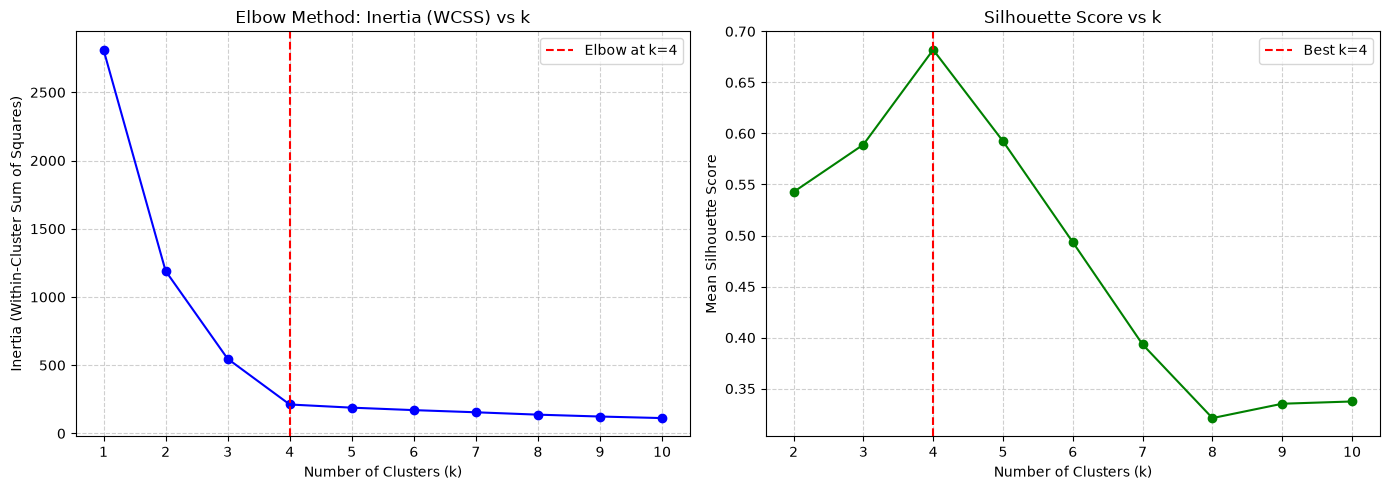


--- Explanation ---
Elbow Method: inertia always decreases as k grows; look for where the rate of decrease sharply flattens (the 'elbow').
Silhouette Score: ranges from -1 to 1, higher is better; pick the k that maximizes the mean silhouette score.
Elbow suggests k=4. Silhouette suggests k=4.
Using both together (rather than just one) gives a more reliable pick of k than either alone.


In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import numpy as np

# 1. Generate a sample dataset with 4 well-separated true clusters
n_samples = 300
n_features = 2
n_true_centers = 4
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_true_centers,
                   cluster_std=0.60, random_state=0)

print(f"Generated dataset with {n_samples} samples, {n_features} features, and {n_true_centers} true centers.")

# 2. Sweep k and record both inertia (Elbow) and silhouette score
k_range = range(2, 11)  # silhouette needs at least 2 clusters, so start at 2
inertia_values = []
silhouette_values = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)  # n_init to avoid bad local optima
    labels = km.fit_predict(X)
    inertia_values.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhouette_values.append(sil)
    print(f"K={k}: Inertia = {km.inertia_:.2f} | Silhouette = {sil:.4f}")

# Also compute inertia for k=1 separately (silhouette is undefined at k=1)
km1 = KMeans(n_clusters=1, random_state=0, n_init=10).fit(X)
full_k_range = [1] + list(k_range)
full_inertia = [km1.inertia_] + inertia_values

# 3. Plot Elbow (left) and Silhouette (right) side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(full_k_range, full_inertia, marker='o', linestyle='-', color='blue')
ax1.set_title('Elbow Method: Inertia (WCSS) vs k')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.set_xticks(full_k_range)
ax1.grid(True, linestyle='--', alpha=0.6)
elbow_k_suggestion = 4  # visually the elbow for this 4-blob dataset
ax1.axvline(x=elbow_k_suggestion, color='red', linestyle='--', label=f'Elbow at k={elbow_k_suggestion}')
ax1.legend()

ax2.plot(list(k_range), silhouette_values, marker='o', linestyle='-', color='green')
ax2.set_title('Silhouette Score vs k')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Mean Silhouette Score')
ax2.set_xticks(list(k_range))
ax2.grid(True, linestyle='--', alpha=0.6)
best_k_sil = list(k_range)[int(np.argmax(silhouette_values))]
ax2.axvline(x=best_k_sil, color='red', linestyle='--', label=f'Best k={best_k_sil}')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n--- Explanation ---")
print("Elbow Method: inertia always decreases as k grows; look for where the rate of decrease sharply flattens (the 'elbow').")
print("Silhouette Score: ranges from -1 to 1, higher is better; pick the k that maximizes the mean silhouette score.")
print(f"Elbow suggests k={elbow_k_suggestion}. Silhouette suggests k={best_k_sil}.")
print("Using both together (rather than just one) gives a more reliable pick of k than either alone.")

## 5. Random Initialization Sensitivity — Local Minima Problem

K-Means's cost surface has many **local minima**: the *final* clustering it converges to depends on where the centroids started. Two runs with different random starting centroids can converge to different (and sometimes clearly worse) solutions, even on the exact same data.

Below we run plain K-Means with `init='random'` and `n_init=1` (i.e. try only ONE random start, no retries) using several different `random_state` values on the same dataset, and show that both the **inertia** and the **actual cluster assignments** differ from run to run — this is the local-minima problem in action.

Then we show the fix: setting `n_init` > 1 (sklearn tries several random/`k-means++` starts and automatically **keeps the run with the lowest inertia**), or simply using the sklearn default `init='k-means++'` with `n_init=10`, produces a stable, near-optimal result regardless of `random_state`.

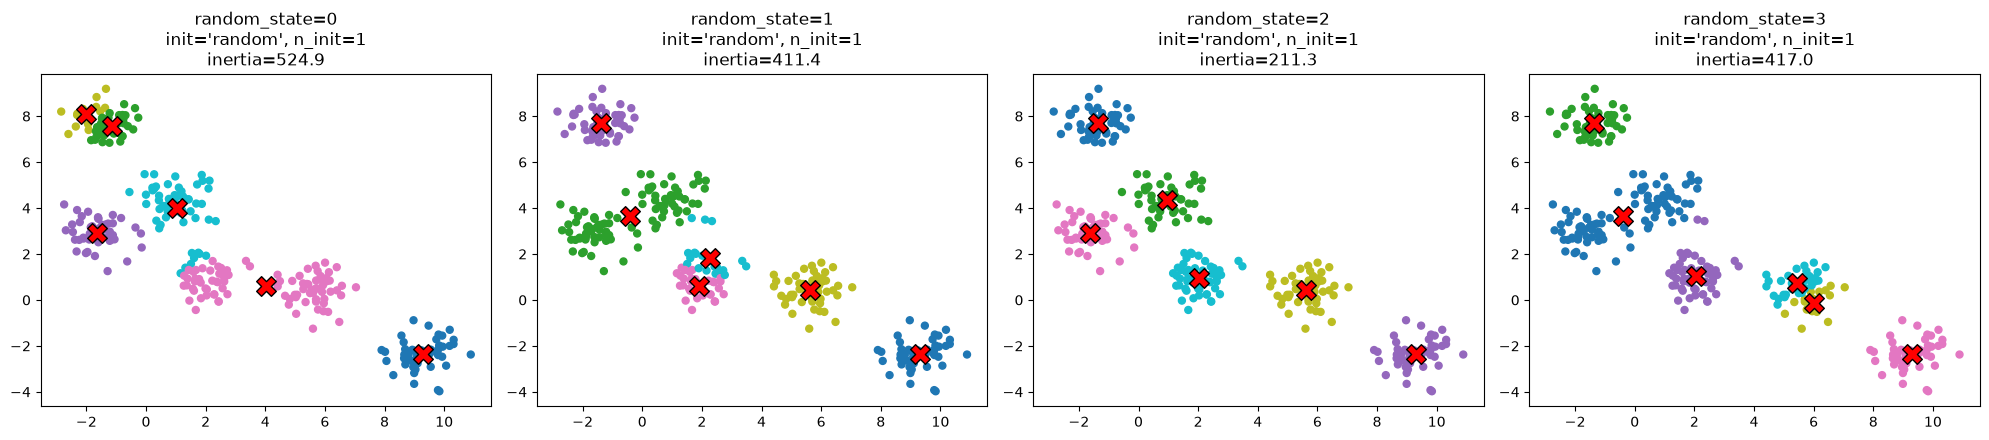

Inertia across different single-random-init runs: [524.87, 411.4, 211.31, 417.0]
Notice these differ -> different random_state / single random start can land in different local minima.

Inertia across the same random_states, but with init='k-means++' and n_init=10:
[211.31, 211.31, 211.31, 211.31]

These are now essentially identical and close to the true minimum -- sklearn ran n_init
independent initializations internally and kept only the single best (lowest-inertia) result.
This is exactly why sklearn's KMeans defaults are init='k-means++' and n_init>=10 (modern sklearn: n_init='auto').


In [15]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

# Reuse a dataset where bad initialization can visibly go wrong
X_init, _ = make_blobs(n_samples=300, centers=6, cluster_std=0.60, random_state=0)  # 6 close-ish centers -> local minima actually occur

# --- Problem: single random init (n_init=1), several random_states ---
seeds = [0, 1, 2, 3]
fig, axes = plt.subplots(1, len(seeds), figsize=(5 * len(seeds), 4.5))

single_init_inertias = []
for ax, seed in zip(axes, seeds):
    km_bad = KMeans(n_clusters=6, init='random', n_init=1, random_state=seed)
    labels_bad = km_bad.fit_predict(X_init)
    single_init_inertias.append(km_bad.inertia_)
    ax.scatter(X_init[:, 0], X_init[:, 1], c=labels_bad, cmap='tab10', s=25)
    ax.scatter(km_bad.cluster_centers_[:, 0], km_bad.cluster_centers_[:, 1],
               c='red', marker='X', s=200, edgecolor='black')
    ax.set_title(f"random_state={seed}\ninit='random', n_init=1\ninertia={km_bad.inertia_:.1f}")

plt.tight_layout()
plt.show()

print("Inertia across different single-random-init runs:", [round(v, 2) for v in single_init_inertias])
print("Notice these differ -> different random_state / single random start can land in different local minima.\n")

# --- Fix: k-means++ init with n_init > 1 (sklearn's default behaviour) ---
fixed_inertias = []
for seed in seeds:
    km_good = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=seed)
    km_good.fit(X_init)
    fixed_inertias.append(km_good.inertia_)

print("Inertia across the same random_states, but with init='k-means++' and n_init=10:")
print([round(v, 2) for v in fixed_inertias])
print("\nThese are now essentially identical and close to the true minimum -- sklearn ran n_init")
print("independent initializations internally and kept only the single best (lowest-inertia) result.")
print("This is exactly why sklearn's KMeans defaults are init='k-means++' and n_init>=10 (modern sklearn: n_init='auto').")

**Takeaway:** never trust a single random K-Means run for anything important. `k-means++` gives smarter starting centroids (spread apart, not clumped), and `n_init > 1` runs the whole algorithm several times and automatically keeps the best (lowest-inertia) result — this is why it's the scikit-learn default.

## 6. Where K-Means Fails — Non-Spherical Clusters (foreshadowing DBSCAN)

K-Means implicitly assumes clusters are roughly **spherical/convex and similarly sized**, because it only ever compares "distance to a single center point". On data shaped like interleaving crescents (`make_moons`), that assumption breaks down completely — K-Means will cut straight across the two crescents rather than following their curved shape, no matter how well it's tuned.

This is exactly the kind of dataset **DBSCAN** (density-based clustering) is built for, since DBSCAN groups points by *density-connectivity* rather than distance-to-a-center, and can trace arbitrary shapes. See the sibling folder `Unsupervised/DBSCAN (Density-Based Clustering)/README.md` for the full deep dive into DBSCAN — this section is just a quick illustration of the failure mode, not a replacement for it.

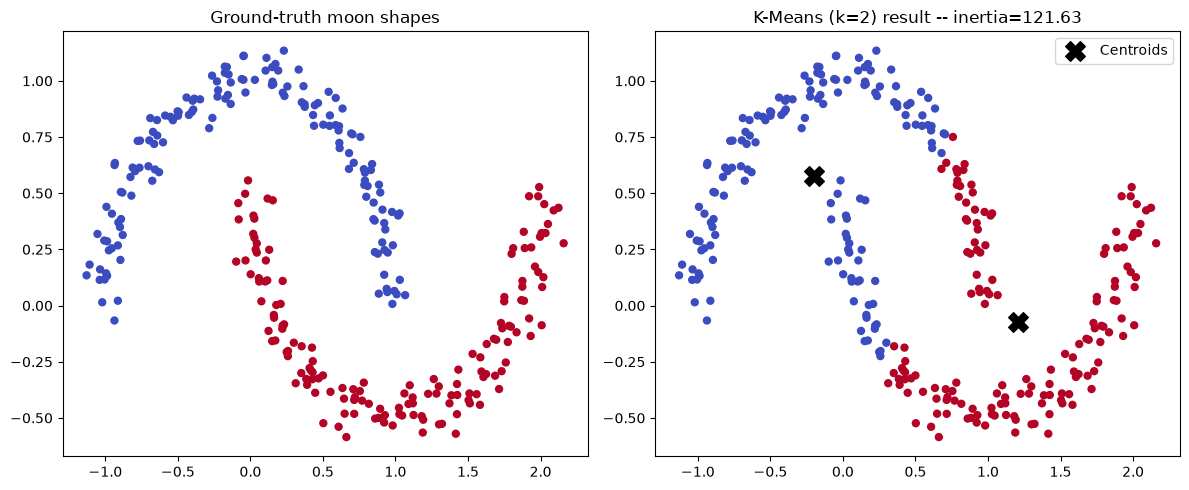

K-Means slices the two moons with a straight-line-ish boundary through the middle,
mixing points from both crescents, because it can only reason about distance-to-centroid --
it has no notion of the curved, density-connected shape of each moon.
DBSCAN (density-based) handles this correctly by following density instead of distance-to-center.


In [16]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_moons, y_moons_true = make_moons(n_samples=300, noise=0.06, random_state=42)

km_moons = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
labels_moons = km_moons.fit_predict(X_moons)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_true, cmap='coolwarm', s=25)
ax1.set_title("Ground-truth moon shapes")

ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons, cmap='coolwarm', s=25)
ax2.scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
            c='black', marker='X', s=200, label='Centroids')
ax2.set_title(f"K-Means (k=2) result -- inertia={km_moons.inertia_:.2f}")
ax2.legend()

plt.tight_layout()
plt.show()

print("K-Means slices the two moons with a straight-line-ish boundary through the middle,")
print("mixing points from both crescents, because it can only reason about distance-to-centroid --")
print("it has no notion of the curved, density-connected shape of each moon.")
print("DBSCAN (density-based) handles this correctly by following density instead of distance-to-center.")

## Summary

This notebook now contains, in learning order: theory (centroid, Lloyd's algorithm, SSE/inertia, why cost monotonically decreases) -> hands-on manual/visual intuition -> full scikit-learn workflow on Iris -> two complementary ways to pick k (Elbow + Silhouette) -> the random-init/local-minima pitfall and its `k-means++`/`n_init` fix -> a quick demo of where K-Means breaks down (non-spherical `make_moons` data), pointing to DBSCAN as the next algorithm to study.

For the full theory write-up (formulas, hand-worked numeric example, hyperparameter table, comparisons with DBSCAN/Hierarchical/GMM, pitfalls), see `README.md` in this same folder.